In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    MinMaxScaler,
    PowerTransformer,
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


from imblearn.under_sampling import RandomUnderSampler


import joblib


from src.config import (
    CLUSTERED_DATA
)
from src.models import (
    get_cv_results,
    organize_results
)
from src.graphics import (
    compare_metrics
)

In [2]:
df = pd.read_parquet(CLUSTERED_DATA)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Age,MntTotal,MntRegularProds,Children,hasChildren,AcceptedCmpTotal,HasAcceptedCmp,NumPurchasesTotal,AgeGroup,cluster
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,57,1617,1529,0,0,0,0,22,46-60,1
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,60,27,21,2,1,0,0,4,46-60,0
2,Graduation,Partner,71613.0,0,0,26,426,49,127,111,...,49,776,734,0,0,0,0,20,46-60,1
3,Graduation,Partner,26646.0,1,0,26,11,4,20,10,...,30,53,48,1,1,0,0,6,18-30,0
4,PhD,Partner,58293.0,1,0,94,173,43,118,46,...,33,422,407,1,1,0,0,14,31-45,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Education            2187 non-null   object  
 1   Marital_Status       2187 non-null   object  
 2   Income               2187 non-null   float64 
 3   Kidhome              2187 non-null   int64   
 4   Teenhome             2187 non-null   int64   
 5   Recency              2187 non-null   int64   
 6   MntWines             2187 non-null   int64   
 7   MntFruits            2187 non-null   int64   
 8   MntMeatProducts      2187 non-null   int64   
 9   MntFishProducts      2187 non-null   int64   
 10  MntSweetProducts     2187 non-null   int64   
 11  MntGoldProds         2187 non-null   int64   
 12  NumDealsPurchases    2187 non-null   int64   
 13  NumWebPurchases      2187 non-null   int64   
 14  NumCatalogPurchases  2187 non-null   int64   
 15  NumStorePurchases    

In [4]:
X = df.drop("Response", axis=1)
y = df["Response"]

In [5]:
# Definindo a transformação de cada coluna

min_max_columns = [
    "Recency",
    "DaysSinceEnrolled",
]

std_columns = [
    "Income",
    "Age",
]

power_columns = X.columns[
    X.columns.str.startswith("Mnt") |
    X.columns.str.startswith("Num")
].tolist()

one_hot_columns = X.columns.difference(
    min_max_columns + std_columns + power_columns
).tolist()

In [6]:
# Definição do pré-processamento das colunas
preprocessing = ColumnTransformer(
    [
        ("ohe", OneHotEncoder(drop="first"), one_hot_columns),
        ("std", StandardScaler(), std_columns),
        ("min_max", MinMaxScaler(), min_max_columns),
        ("power", PowerTransformer(), power_columns),
    ]
)

tree_preprocessing = ColumnTransformer(
    [
        ("ohe", OneHotEncoder(drop="first"), one_hot_columns),
    ]
)

In [7]:
RANDOM_STATE = 42

In [8]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)

In [9]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [10]:
classificators = {
    "DummyClassifier": {
        "feat_selection": None,
        "resampler": None,
        "preprocessing": None,
        "classificator": DummyClassifier(
            strategy="stratified",
            random_state=RANDOM_STATE
        ),
    },
    "LogisticRegression": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": preprocessing,
        "classificator": LogisticRegression(
            random_state=RANDOM_STATE
        ),
    },
    "DecisionTreeClassifier": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": tree_preprocessing,
        "classificator": DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),
    },
    "XGBClassifier": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": tree_preprocessing,
        "classificator": XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    },
    "LGBMClassifier": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": tree_preprocessing,
        "classificator": LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
    },
    "SVC": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": preprocessing,
        "classificator": SVC(
            random_state=RANDOM_STATE
        ),
    },
    "KNeigborsClassifier": {
        "feat_selection": SelectKBest(f_classif, k=10),
        "resampler": rus,
        "preprocessing": preprocessing,
        "classificator": KNeighborsClassifier(),
    },
}

In [11]:
results = {
    name: get_cv_results(X, y, kf, **classificator) 
    for name, classificator in classificators.items()
}
print(results)

/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucas/Documentos/python/ifood_analyst/venv/lib/python3.11/site-packages/sklearn/ut

{'DummyClassifier': {'fit_time': array([0.00340629, 0.00254965, 0.00162458, 0.0025878 , 0.00307822]), 'score_time': array([0.01449299, 0.01283026, 0.01382995, 0.01532435, 0.01518321]), 'test_accuracy': array([0.76027397, 0.74200913, 0.74828375, 0.76659039, 0.75286041]), 'test_precision': array([0.171875  , 0.109375  , 0.12698413, 0.19047619, 0.140625  ]), 'test_recall': array([0.17460317, 0.11111111, 0.12698413, 0.19047619, 0.14516129]), 'test_f1': array([0.17322835, 0.11023622, 0.12698413, 0.19047619, 0.14285714]), 'test_roc_auc': array([0.51663492, 0.47955556, 0.48996265, 0.52705628, 0.49924731]), 'test_average_precision': array([0.14873138, 0.14000666, 0.14198309, 0.15298598, 0.14169477])}, 'LogisticRegression': {'fit_time': array([0.12542057, 0.09362316, 0.07074022, 0.0717175 , 0.07736588]), 'score_time': array([0.03799081, 0.0407908 , 0.02944565, 0.03321528, 0.02958465]), 'test_accuracy': array([0.80136986, 0.82876712, 0.81006865, 0.77574371, 0.76659039]), 'test_precision': array(

In [12]:
df_results = organize_results(results)
df_results

,model,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,total_time
0,DummyClassifier,0.003406,0.014493,0.760274,0.171875,0.174603,0.173228,0.516635,0.148731,0.017899
0,DummyClassifier,0.00255,0.01283,0.742009,0.109375,0.111111,0.110236,0.479556,0.140007,0.01538
0,DummyClassifier,0.001625,0.01383,0.748284,0.126984,0.126984,0.126984,0.489963,0.141983,0.015455
0,DummyClassifier,0.002588,0.015324,0.76659,0.190476,0.190476,0.190476,0.527056,0.152986,0.017912
0,DummyClassifier,0.003078,0.015183,0.75286,0.140625,0.145161,0.142857,0.499247,0.141695,0.018261
1,LogisticRegression,0.125421,0.037991,0.80137,0.390909,0.68254,0.49711,0.819386,0.45299,0.163411
1,LogisticRegression,0.093623,0.040791,0.828767,0.434783,0.634921,0.516129,0.827683,0.566214,0.134414
1,LogisticRegression,0.07074,0.029446,0.810069,0.4,0.634921,0.490798,0.816696,0.443145,0.100186
1,LogisticRegression,0.071718,0.033215,0.775744,0.315789,0.47619,0.379747,0.741109,0.377571,0.104933
1,LogisticRegression,0.077366,0.029585,0.76659,0.333333,0.645161,0.43956,0.786882,0.466337,0.106951


In [13]:
df_results.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,total_time
model,,,,,,,,,
DummyClassifier,0.002649,0.014332,0.754004,0.147867,0.149667,0.148756,0.502491,0.14508,0.016981
KNeigborsClassifier,0.052718,0.026946,0.719702,0.296469,0.694368,0.414592,0.769681,0.343156,0.079663
DecisionTreeClassifier,0.01662,0.020137,0.775912,0.351835,0.617921,0.444755,0.762045,0.398879,0.036758
SVC,0.05668,0.031194,0.785074,0.368475,0.665643,0.472808,0.799771,0.41138,0.087875
XGBClassifier,0.131398,0.024681,0.773623,0.349427,0.617921,0.442634,0.766595,0.431265,0.156079
LGBMClassifier,0.052076,0.026277,0.775454,0.353978,0.630722,0.449531,0.76906,0.444799,0.078353
LogisticRegression,0.087773,0.034205,0.796508,0.374963,0.614747,0.464669,0.798351,0.461251,0.121979


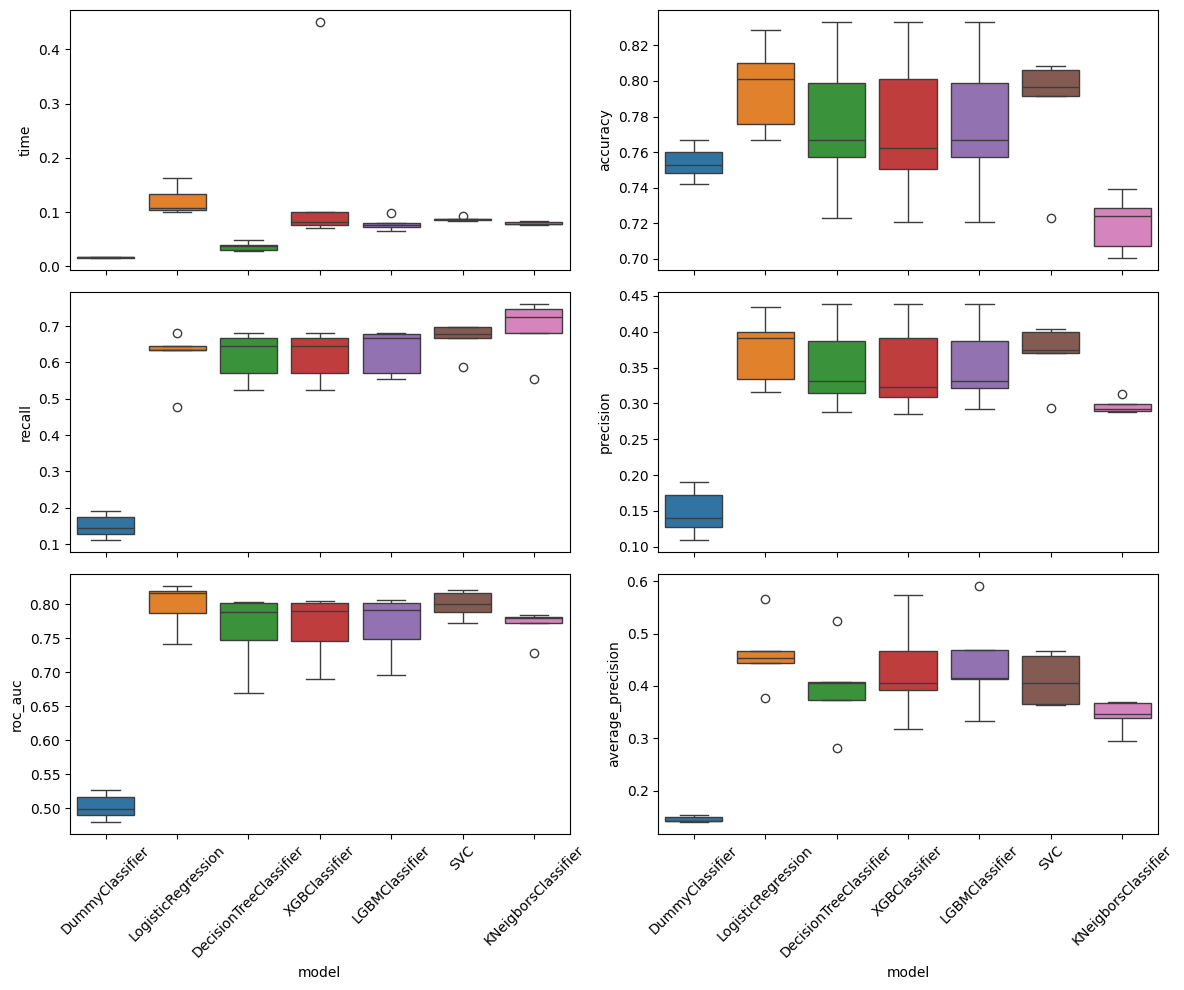

In [14]:
compare_metrics(df_results)